In [1]:
%load_ext autoreload
%autoreload 2

In [32]:
import matplotlib.pyplot as plt
from magpylib import magnet
from magpylib_material_response import demag, meshing
from time import perf_counter
from nn_magnetics.models import SphericalCorrectionNetwork
from nn_magnetics.data import AnisotropicData
from nn_magnetics.utils.physics import Bfield_homogeneous
import torch
from pathlib import Path

In [3]:
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 16,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

labels = ["Component", "Euler", "Quaternion"]
colors_ = ["#784c99", "#6780be", "#e93ea5"]
markers = ["v", "o", "*"]

In [4]:
SAVE_PATH = Path(
    "/Users/jacksmith/Documents/work/nn-magnetics/results/3dof_chi_spherical/2025-05-13 16:36:35.129285"
)

In [33]:
def time_analytical(x, cuboid, n_samples, n_repeats, dimensions):
    observers = x[:n_samples, 5:]
    polarizations = torch.tensor([0, 0, 1]).expand((observers.shape[0], -1))
    dimensions = torch.tensor(dimensions).expand((observers.shape[0], -1))

    total_time = 0
    for _ in range(n_repeats):
        start = perf_counter()
        _ = Bfield_homogeneous(observers=observers, dimensions=dimensions, polarizations=polarizations)
        end = perf_counter()

        total_time += end - start

    return total_time / n_repeats


def time_demag(x, mesh, n_samples, n_repeats, susceptibility):
    observers = x[:n_samples, 5:].numpy()

    total_time = 0
    for _ in range(n_repeats):
        start = perf_counter()
        demag.apply_demag(mesh, susceptibility=susceptibility, inplace=True)
        _ = mesh.getB(observers)
        end = perf_counter()

        total_time += end - start

    return total_time / n_repeats


def time_nn(x, model, n_samples, n_repeats):
    observers = x[:n_samples, :]

    total_time = 0
    for _ in range(n_repeats):
        start = perf_counter()
        _ = model(observers)
        end = perf_counter()

        total_time += end - start

    return total_time / n_repeats

In [6]:
X, B = AnisotropicData(
    "../data/3dof_chi_v3/small/validation",
    dtype=torch.float32,
).get_magnets()
x = X[0]
a, b = x[0, 0], x[0, 1]
susceptibility = x[0, 2:5]

In [7]:
cuboid = magnet.Cuboid(dimension=(a, b, 1), polarization=(0, 0, 1))

In [8]:
cuboid = magnet.Cuboid(dimension=(a, b, 1), polarization=(0, 0, 1))
mesh = meshing.mesh_Cuboid(cuboid=cuboid, target_elems=100)

In [9]:
model = SphericalCorrectionNetwork.load_from_path(
    SAVE_PATH / "best_weights.pt",
    activation=torch.nn.functional.silu,
    save_path=None,
    save_weights=False,
    do_output_activation=False,
)

In [36]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 16834, 65536, 262144]
# batch_sizes = [1, 2, 4, 8, 16, 32]
n_repeats = 100

In [37]:
times_analytical = [
    time_analytical(x=x, cuboid=cuboid, n_samples=b, n_repeats=n_repeats, dimensions=[a, b, 1])
    for b in batch_sizes
]

In [12]:
times_demag = [
    time_demag(x=x, mesh=mesh, n_samples=b, n_repeats=n_repeats, susceptibility=susceptibility) 
    for b in batch_sizes
]

2025-07-18 at 16:24:55 |   INFO   | run | {} ℹ️ Start Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96})
2025-07-18 at 16:24:56 | SUCCESS  | timelog | {} ✅  Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96}) done 🕑 1.027sec
2025-07-18 at 16:24:58 |   INFO   | run | {} ℹ️ Start Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96})
2025-07-18 at 16:24:58 | SUCCESS  | timelog | {} ✅  Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96}) done 🕑 1.034sec
2025-07-18 at 16:24:59 |   INFO   | run | {} ℹ️ Start Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96})
2025-07-18 at 16:24:59 | SUCCESS  | timelog | {} ✅  Demagnetization (inplace) of Collection(id=4913099168) with 96 cells - Counter({'Cuboid': 96}) done 🕑 1.027sec
2025-07-18 at 16:25:00 |   INFO   | run | {} ℹ️ Start Demagnetiz

In [38]:
times_nn = [
    time_nn(x=x, model=model, n_samples=b, n_repeats=n_repeats) 
    for b in batch_sizes
]

In [14]:
def ns_to_s(times):
    return [t * 1e-9 for t in times]

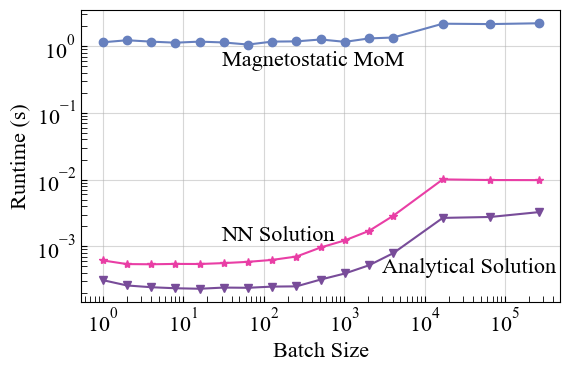

In [49]:
def plot_times(batch_sizes, times_ana, times_demag, times_nn):
    assert len(times_ana) == len(times_demag) == len(times_nn)

    fig, ax = plt.subplots(figsize = (6, 4))

    ax.plot(
        batch_sizes,
        times_demag,
        label="Full Solution",
        color=colors_[1],
        marker=markers[1],
    )
    ax.annotate("Magnetostatic MoM", xy=(3e1, 5e-1))

    ax.plot(
        batch_sizes,
        times_ana,
        label="Analytical solution",
        color=colors_[0],
        marker=markers[0],
    )
    ax.annotate("Analytical Solution", xy=(3e3, 4e-4))


    ax.plot(
        batch_sizes,
        times_nn,
        label="NN Solution",
        color=colors_[2],
        marker=markers[2],
    )
    ax.annotate("NN Solution", xy=(3e1, 1.2e-3))

    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("Batch Size")

    ax.set_ylabel("Runtime (s)")
    ax.grid(alpha=0.5)
    ax.tick_params(
        axis="both",  # Apply to both x and y axis
        which="both",  # Apply to both major and minor ticks
        direction="in",  # Tick direction 'in' for inside the plot
        top=False,  # Show ticks on top
        right=False,  # Show ticks on right
        length=4,
    )
    plt.tight_layout()
    plt.savefig("./runtimes.pdf", format="pdf")


plot_times(batch_sizes, times_analytical, times_demag, times_nn)
